# Data Audit -- Italian Architects Wikipedia Dataset
**MBL549E Case Study 3**

8 Italian architects, 211 buildings, 16 columns scraped from Wikipedia.

| Step | Content |
|---|---|
| 1 | Data Consistency Check |
| 2 | Missing Data Analysis |
| 3 | Outlier Analysis (IQR - Geographic) |
| 4 | Distribution & Statistical Summary |
| 5 | Repeated Data Check |
| 6 | Bias Check |
| 7 | Semantic Outlier (TF-IDF + Cosine Distance) |


## Setup

In [1]:
!pip install missingno -q

import pickle
import re
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

sns.set_theme(style='whitegrid', palette='muted')

with open('dataset.pkl', 'rb') as f:
    df = pickle.load(f)

def parse_coords(val):
    if pd.isna(val): return None, None
    m = re.match(r'([\d.]+)deg([NS])\s([\d.]+)deg([EW])', str(val).replace('°','deg'))
    if m:
        lat = float(m.group(1)) * (1 if m.group(2)=='N' else -1)
        lon = float(m.group(3)) * (1 if m.group(4)=='E' else -1)
        return lat, lon
    return None, None

df['latitude'], df['longitude'] = zip(*df['coordinates'].apply(parse_coords))
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded: 211 rows x 18 columns


## 1. Data Consistency Check

Three checks:
- Unique data types per column
- `coordinates` format (regex)
- Unexpected values in raw categorical columns


In [2]:
# 1.1 Unique data types per column
print('Unique data types per column:')
print('-' * 52)
for col in df.columns:
    types = df[col].dropna().apply(lambda x: type(x).__name__).unique()
    flag = '  WARNING: MIXED TYPE' if len(types) > 1 else ''
    print(f'  {col:25s}: {list(types)}{flag}')


Unique data types per column:
----------------------------------------------------
  url                      : ['str']
  title                    : ['str']
  country                  : ['str']
  building_type            : ['str']
  coordinates              : ['str']
  paragraphs               : ['list']
  first_image_url          : ['str']
  img_npy                  : ['ndarray']
  architect                : ['str']
  architect_period         : ['str']
  full_text                : ['str']
  country_normalized       : ['str']
  country_top              : ['str']
  building_type_group      : ['str']
  architect_label          : ['str']
  period_rank              : ['int']
  latitude                 : ['float']
  longitude                : ['float']


In [3]:
# 1.2 Coordinates format check
def check_coord_format(val):
    if pd.isna(val): return 'missing'
    return 'valid' if re.match(r'^[\d.]+°[NS]\s[\d.]+°[EW]$', str(val)) else 'invalid'

df['coord_check'] = df['coordinates'].apply(check_coord_format)
print('Coordinates format distribution:')
print(df['coord_check'].value_counts().to_string())

invalid = df[df['coord_check'] == 'invalid']
if len(invalid):
    print('\nInvalid format examples:')
    print(invalid[['title', 'coordinates']].to_string())
else:
    print('\nAll coordinates follow the expected format.')


Coordinates format distribution:
coord_check
valid      203
missing      8

All coordinates follow the expected format.


In [4]:
# 1.3 Unexpected values in raw categorical columns
print('Raw country values (top 20):')
print(df['country'].dropna().value_counts().head(20).to_string())
print()
print('Raw building_type values (top 20):')
print(df['building_type'].dropna().value_counts().head(20).to_string())


Raw country values (top 20):
country
Italy                                                63
Rome                                                 20
U.S.                                                  5
United States                                         3
Genoa Italy                                           3
France                                                3
Switzerland                                           2
Germany                                               2
Malta                                                 2
Taiwan                                                2
Russia                                                2
Australia                                             1
Illinois United States                                1
UK                                                    1
New Caledonia                                         1
Georgia                                               1
5905 Wilshire Boulevard Los Angeles United States     1
Texas      

In [5]:
# 1.4 Unique values in normalised categorical columns
for col in ['country_normalized','building_type_group','architect_period']:
    vals = sorted(df[col].dropna().unique().tolist())
    print(f'\n{col} ({len(vals)} unique):')
    for v in vals:
        print(f'  - {v}')



country_normalized (18 unique):
  - Australia
  - Canada
  - Estonia
  - France
  - Germany
  - Italy
  - Japan
  - Malta
  - Netherlands
  - Norway
  - Portugal
  - Russia
  - South Africa
  - Switzerland
  - Taiwan
  - United Kingdom
  - United States
  - unknown

building_type_group (9 unique):
  - commercial/office
  - cultural
  - education
  - healthcare
  - infrastructure
  - public/civic
  - religious
  - residential
  - sports/leisure

architect_period (7 unique):
  - Baroque
  - Contemporary (1937–)
  - Late Baroque (1702–1770)
  - Late Baroque / Neoclassical (1700–1773)
  - Modernist (1891–1979)
  - Neoclassical (1775–1849)
  - Renaissance (1508–1580)


## 2. Missing Data Analysis

| Type | Description |
|---|---|
| **MCAR** | Completely At Random |
| **MAR** | At Random -- related to other observable variables |
| **MNAR** | Not At Random -- related to the missing value itself |


In [6]:
# 2.1 Missing rate table
missing_df = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing Rate %': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Rate %', ascending=False)
print(missing_df.to_string())


                     Missing Count  Missing Rate %
first_image_url                170            80.6
img_npy                        170            80.6
building_type                  150            71.1
country                         71            33.6
longitude                        8             3.8
latitude                         8             3.8
coordinates                      8             3.8
title                            0             0.0
url                              0             0.0
paragraphs                       0             0.0
architect                        0             0.0
full_text                        0             0.0
architect_period                 0             0.0
country_normalized               0             0.0
country_top                      0             0.0
architect_label                  0             0.0
building_type_group              0             0.0
period_rank                      0             0.0
coord_check                    

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


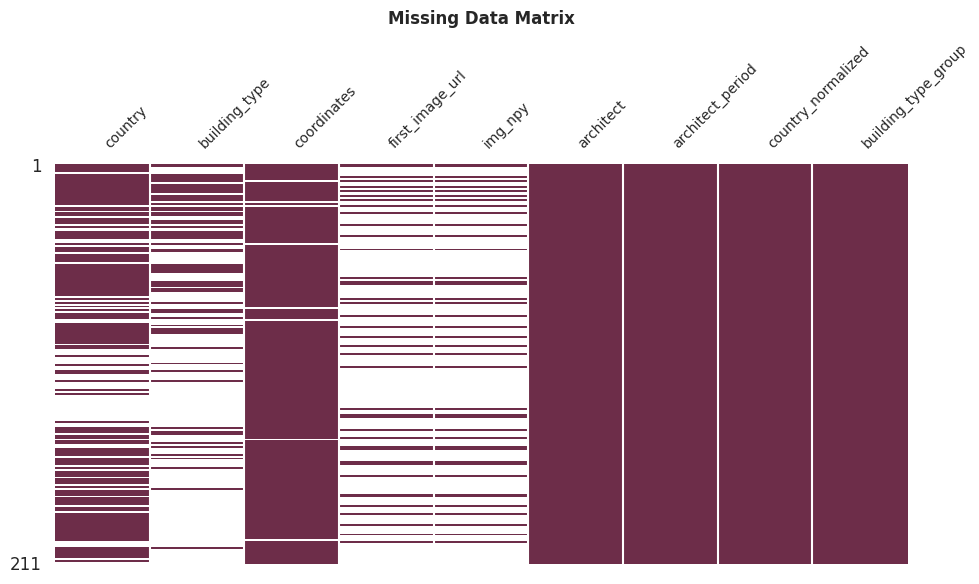

In [7]:
# 2.2 Missing data matrix — Before vs After TF-IDF Enrichment

C2 = (0.43, 0.18, 0.29)

# ── BEFORE: raw infobox columns (have missing values) ──────────────────────
before_cols = ['country', 'building_type', 'coordinates',
               'first_image_url', 'img_npy']

# ── AFTER: TF-IDF-enriched + always-present columns ────────────────────────
after_cols  = ['country_normalized', 'building_type_group',
               'coordinates', 'first_image_url', 'img_npy',
               'architect', 'architect_period']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Before ---
msno.matrix(df[before_cols], ax=axes[0],
            color=C2, fontsize=10)
axes[0].set_title(
    'BEFORE TF-IDF Enrichment\n(Raw Infobox Columns)',
    fontsize=12, fontweight='bold', pad=12, color='#4A1F2D'
)

# --- Right: After ---
msno.matrix(df[after_cols], ax=axes[1],
            color=C2, fontsize=10)
axes[1].set_title(
    'AFTER TF-IDF Enrichment\n(Normalized Columns — 0% Missing)',
    fontsize=12, fontweight='bold', pad=12, color='#4A1F2D'
)

plt.suptitle(
    'Missing Data: Before vs After TF-IDF Enrichment\n'
    'country → country_normalized  |  building_type → building_type_group',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('missing_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Left panel  (BEFORE): raw infobox — country and building_type have missing values.")
print("Right panel (AFTER) : TF-IDF normalized columns — no missing values remain.")


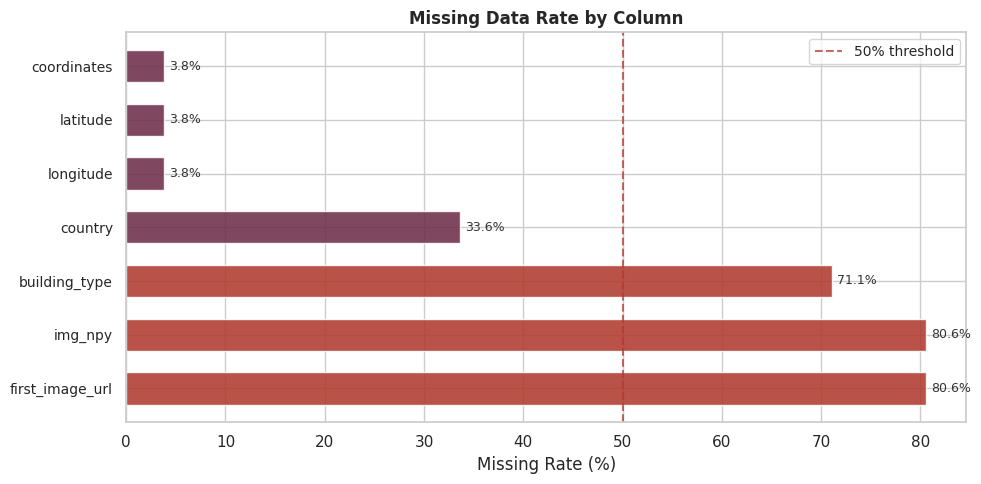

In [8]:
# 2.3 Missing rate bar chart
C2, C3, CRED = '#6E2F4A', '#A85C73', '#B03A2E'
missing_plot = missing_df[missing_df['Missing Rate %'] > 0].copy()
bar_colors = [CRED if v > 50 else C2 for v in missing_plot['Missing Rate %']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_plot.index, missing_plot['Missing Rate %'],
               color=bar_colors, alpha=0.88, height=0.6)
ax.axvline(x=50, color=CRED, linestyle='--', alpha=0.75,
           linewidth=1.5, label='50% threshold')
for bar, val in zip(bars, missing_plot['Missing Rate %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9, color='#333')
ax.set_xlabel('Missing Rate (%)', fontsize=12)
ax.set_title('Missing Data Rate by Column', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('missing_rate.png', dpi=300, bbox_inches='tight')
plt.show()


building_type null rate by architect:
architect
Bernardo Antonio Vittone      100.0
Andrea Palladio                95.9
Carlo Rossi and structures     85.0
Luigi Vanvitelli               73.3
Francesco Borromini            66.7
Pier Luigi Nervi               65.2
Renzo Piano                    43.6
Carlo Maderno                  42.9

country null rate by architect:
architect
Bernardo Antonio Vittone      85.0
Carlo Rossi and structures    75.0
Luigi Vanvitelli              46.7
Pier Luigi Nervi              30.4
Andrea Palladio               22.4
Renzo Piano                   21.8
Francesco Borromini           13.3
Carlo Maderno                  0.0


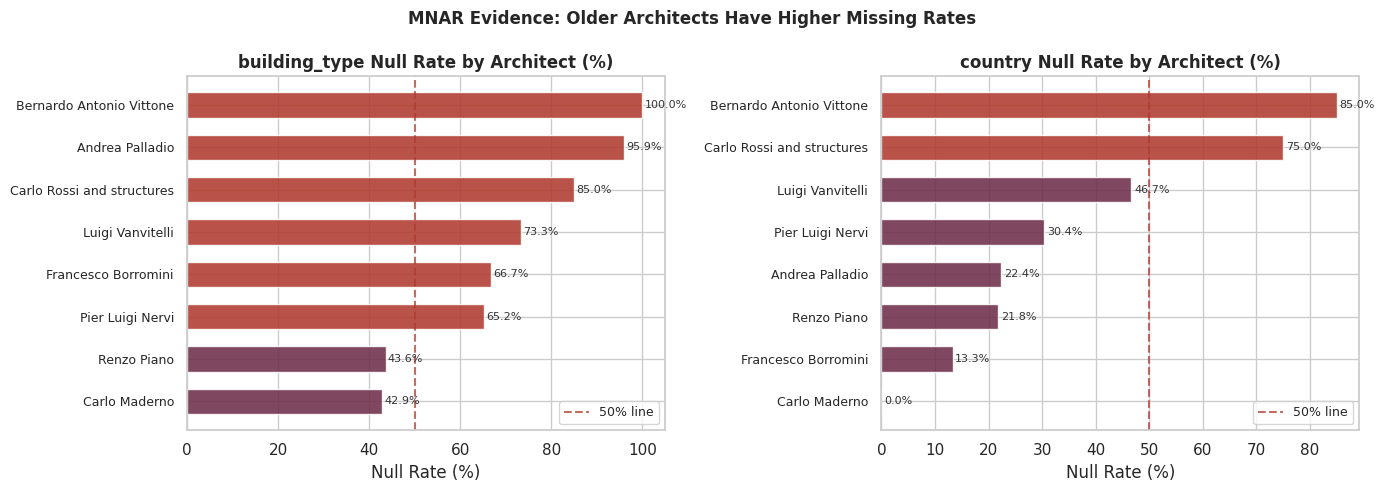

building_type -> MNAR: Vittone 100%, Palladio 96% missing.
country       -> MNAR: Vittone 85%, Carlo Rossi 75% missing.
first_image_url/img_npy -> MNAR: older buildings lack Wikipedia photos.
coordinates   -> MCAR: randomly distributed, no systematic pattern.


In [9]:
# 2.4 MNAR evidence
C2, CRED = '#6E2F4A', '#B03A2E'
bt_miss = df.groupby('architect')['building_type'].apply(
    lambda x: round(x.isna().mean()*100, 1)).sort_values(ascending=True)
c_miss = df.groupby('architect')['country'].apply(
    lambda x: round(x.isna().mean()*100, 1)).sort_values(ascending=True)

print('building_type null rate by architect:')
print(bt_miss.sort_values(ascending=False).to_string())
print('\ncountry null rate by architect:')
print(c_miss.sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, miss_data, title in zip(
    axes,
    [bt_miss, c_miss],
    ['building_type Null Rate by Architect (%)',
     'country Null Rate by Architect (%)']):
    bar_c = [CRED if v > 50 else C2 for v in miss_data]
    bars  = ax.barh(miss_data.index, miss_data.values,
                    color=bar_c, alpha=0.88, height=0.6)
    ax.axvline(x=50, color=CRED, linestyle='--', alpha=0.75,
               linewidth=1.5, label='50% line')
    for bar, val in zip(bars, miss_data.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=8, color='#333')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Null Rate (%)', fontsize=12)
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('MNAR Evidence: Older Architects Have Higher Missing Rates',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mnar_evidence.png', dpi=300, bbox_inches='tight')
plt.show()
print('building_type -> MNAR: Vittone 100%, Palladio 96% missing.')
print('country       -> MNAR: Vittone 85%, Carlo Rossi 75% missing.')
print('first_image_url/img_npy -> MNAR: older buildings lack Wikipedia photos.')
print('coordinates   -> MCAR: randomly distributed, no systematic pattern.')


## 3. Outlier Analysis (IQR -- Geographic)

`coordinates` parsed into `latitude` and `longitude`. IQR detects buildings geographically distant from the dataset core (Italy / Western Europe).

- Lower bound = Q1 - 1.5 x IQR
- Upper bound = Q3 + 1.5 x IQR


In [10]:
# 3.1 IQR calculation
for col in ['latitude','longitude']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1-1.5*IQR, Q3+1.5*IQR
    n_out = ((df[col]<lower)|(df[col]>upper)).sum()
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, '
          f'lower={lower:.2f}, upper={upper:.2f}, outliers={n_out}')


latitude: Q1=41.90, Q3=45.61, IQR=3.71, lower=36.34, upper=51.17, outliers=42
longitude: Q1=7.86, Q3=12.49, IQR=4.63, lower=0.92, upper=19.44, outliers=51


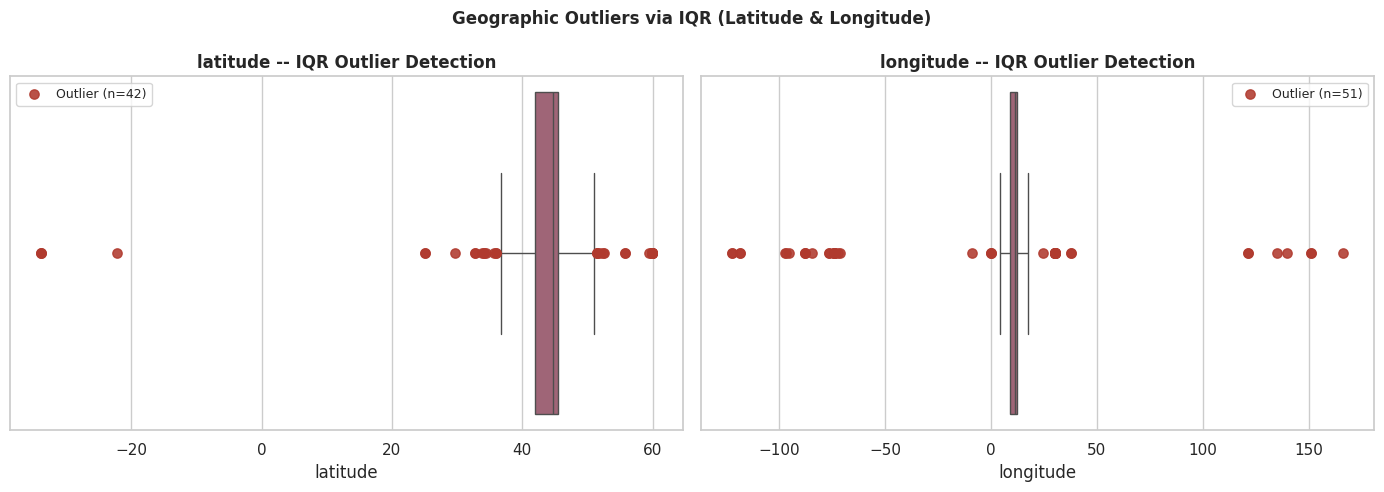

In [11]:
# 3.2 Horizontal boxplot, outliers vurgulu
C2, C3, CRED = '#6E2F4A', '#A85C73', '#B03A2E'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['latitude', 'longitude']):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR   = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier_vals = data[(data < lower) | (data > upper)]
    non_outlier  = data[(data >= lower) & (data <= upper)]
    sns.boxplot(x=non_outlier, ax=ax, orient='h',
                color=C3, width=0.4,
                flierprops=dict(marker=''))
    ax.scatter(outlier_vals, [0]*len(outlier_vals),
               color=CRED, s=45, zorder=5, alpha=0.88,
               label=f'Outlier (n={len(outlier_vals)})')
    ax.set_title(f'{col} -- IQR Outlier Detection',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.legend(fontsize=9)
plt.suptitle('Geographic Outliers via IQR (Latitude & Longitude)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('geo_outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# 3.3 Geographic outlier building list
geo_out = pd.DataFrame()
for col in ['latitude','longitude']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3-Q1
    out = df[(df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)].copy()
    out['outlier_col'] = col
    geo_out = pd.concat([geo_out, out])

geo_out = geo_out.drop_duplicates(subset='title')
print(f'Unique geographic outlier buildings: {len(geo_out)}')
print(geo_out[['title','architect','country_normalized',
               'latitude','longitude']].sort_values('latitude').to_string())


Unique geographic outlier buildings: 58
                                                         title                   architect country_normalized   latitude   longitude
147                                           Good Hope Centre            Pier Luigi Nervi       South Africa -33.926390   18.431110
139                                           Australia Square            Pier Luigi Nervi          Australia -33.865000  151.207780
7                                                 Aurora Place                 Renzo Piano          Australia -33.864969  151.211953
29                          Jean-Marie Tjibaou Cultural Centre                 Renzo Piano             France -22.256280  166.481930
24                                            Fubon Life Tower                 Renzo Piano             Taiwan  25.039170  121.570000
23                                            Fubon Art Museum                 Renzo Piano             Taiwan  25.039400  121.571100
35                           

## 4. Distribution & Statistical Summary

Numerical: `latitude`, `longitude`, `period_rank` -- Mean, Median, Mode, Std, Skewness, Kurtosis + Histogram & KDE.

Categorical: frequency only (Skewness/Kurtosis not computed).


In [13]:
# 4.1 Statistical summary
num_cols = ['latitude','longitude','period_rank']
for col in num_cols:
    d = df[col].dropna()
    print(f'Column: {col}')
    print(f'  Mean     : {d.mean():.2f}')
    print(f'  Median   : {d.median():.2f}')
    print(f'  Mode     : {d.mode()[0]:.2f}')
    print(f'  Std Dev  : {d.std():.2f}')
    print(f'  Skewness : {skew(d):.3f}')
    print(f'  Kurtosis : {kurtosis(d):.3f}')
    print(f'  Min/Max  : {d.min():.2f} / {d.max():.2f}')
    print()


Column: latitude
  Mean     : 43.52
  Median   : 45.03
  Mode     : 45.55
  Std Dev  : 12.28
  Skewness : -4.314
  Kurtosis : 25.000
  Min/Max  : -33.93 / 59.98

Column: longitude
  Mean     : 6.67
  Median   : 11.55
  Mode     : 8.93
  Std Dev  : 41.02
  Skewness : -0.151
  Kurtosis : 5.049
  Min/Max  : -122.47 / 166.48

Column: period_rank
  Mean     : 3.03
  Median   : 3.00
  Mode     : 6.00
  Std Dev  : 2.37
  Skewness : 0.005
  Kurtosis : -1.601
  Min/Max  : 0.00 / 6.00



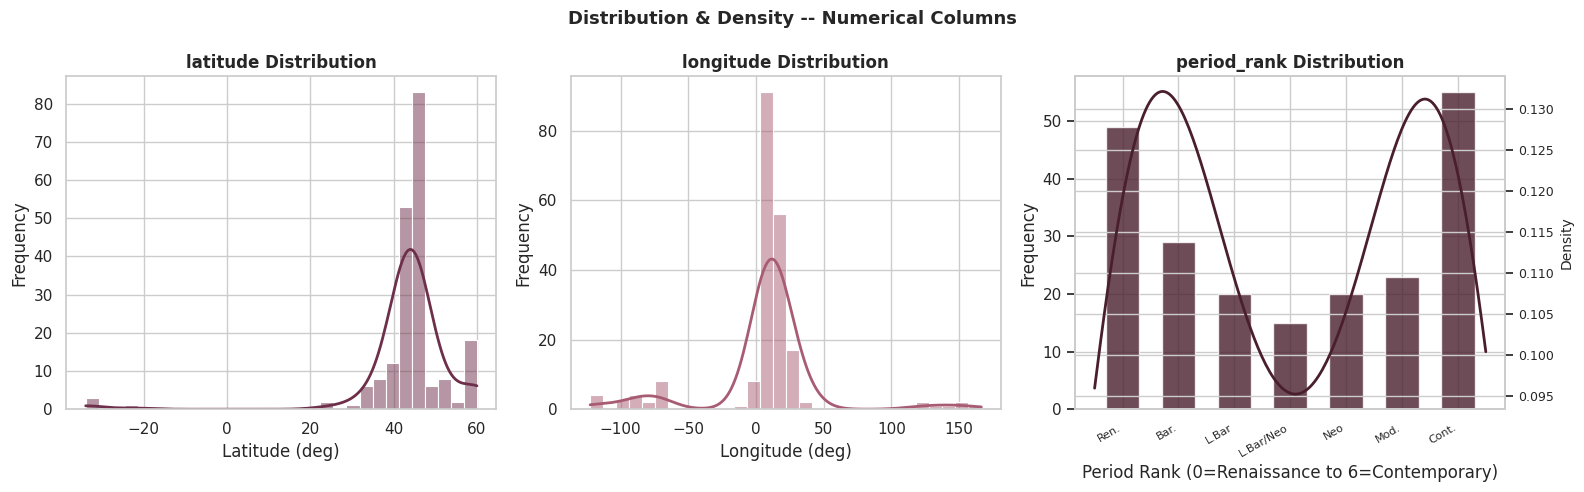

In [14]:
# 4.2 Histogram + KDE
C1, C2, C3 = '#4A1F2D', '#6E2F4A', '#A85C73'
col_labels = {
    'latitude'   : 'Latitude (deg)',
    'longitude'  : 'Longitude (deg)',
    'period_rank': 'Period Rank (0=Renaissance to 6=Contemporary)'
}
col_colors = {'latitude': C2, 'longitude': C3, 'period_rank': C1}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['latitude', 'longitude', 'period_rank']):
    color = col_colors[col]
    data  = df[col].dropna()
    if col == 'period_rank':
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color=color,
               alpha=0.80, width=0.6, edgecolor='white')
        ax2 = ax.twinx()
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data, bw_method=0.5)
        xs  = np.linspace(data.min()-0.5, data.max()+0.5, 200)
        ax2.plot(xs, kde(xs), color=color, linewidth=2)
        ax2.set_ylabel('Density', fontsize=10)
        ax2.tick_params(axis='y', labelsize=9)
        ax.set_xticks(range(7))
        ax.set_xticklabels(
            ['Ren.','Bar.','L.Bar','L.Bar/Neo','Neo','Mod.','Cont.'],
            rotation=30, ha='right', fontsize=8)
    else:
        sns.histplot(data=data, kde=True, color=color,
                     bins=30, ax=ax, line_kws={'linewidth': 2})
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col_labels[col], fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

plt.suptitle('Distribution & Density -- Numerical Columns',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_numerical.png', dpi=300, bbox_inches='tight')
plt.show()


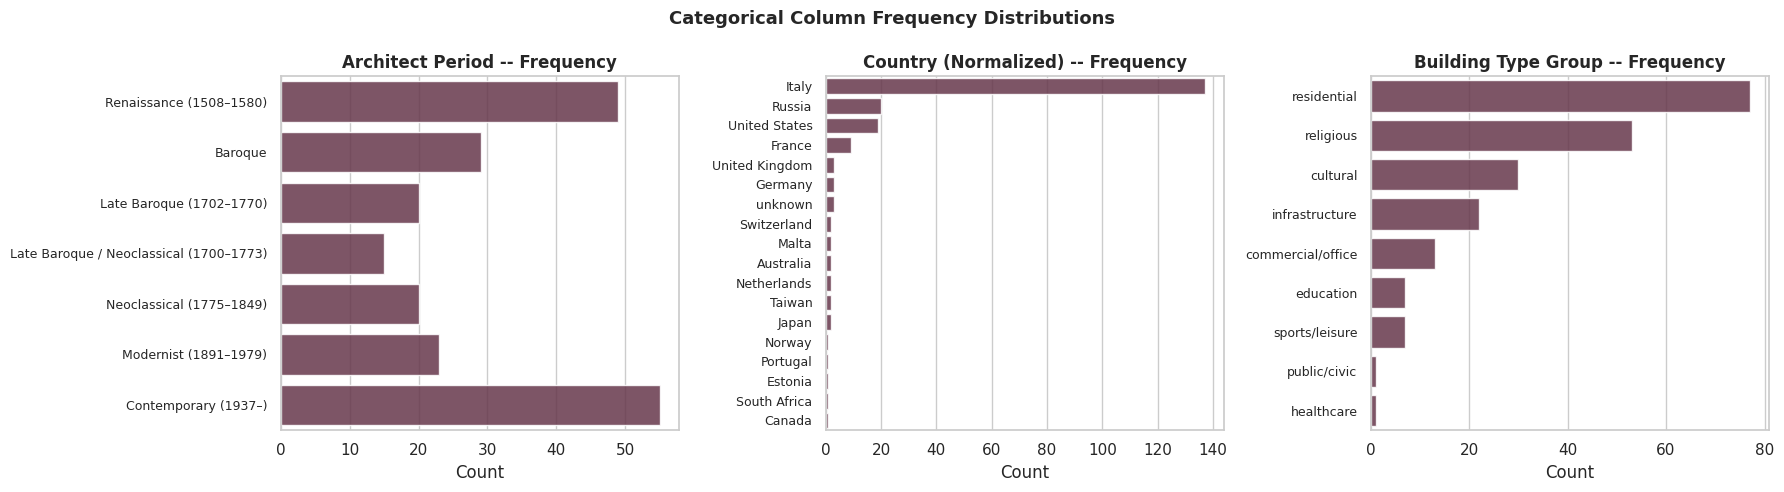

In [15]:
# 4.3 Categorical frequency distributions
C2 = '#6E2F4A'
period_order = [
    'Renaissance (1508–1580)', 'Baroque',
    'Late Baroque (1702–1770)', 'Late Baroque / Neoclassical (1700–1773)',
    'Neoclassical (1775–1849)', 'Modernist (1891–1979)', 'Contemporary (1937–)'
]
cat_settings = [
    ('architect_period',   'Architect Period'),
    ('country_normalized', 'Country (Normalized)'),
    ('building_type_group','Building Type Group'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, cat_settings):
    order = (period_order if col == 'architect_period'
             else df[col].value_counts().index.tolist())
    sns.countplot(data=df, y=col, order=order,
                  color=C2, alpha=0.85, ax=ax)
    ax.set_title(f'{title} -- Frequency', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Categorical Column Frequency Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_categorical.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Repeated Data Check

Duplicate detection based on URL -- same building attributed to multiple architects.


In [16]:
# 5.1 URL-based duplicate detection
dup_url = df[df['url'].duplicated(keep=False)].copy()
print(f'Duplicate URL records (all copies): {len(dup_url)}')
print()
print(dup_url[['title','architect','url']].sort_values('title').to_string())
print()
print('Interpretation: 6 records = 3 buildings co-designed by two architects.')
print('This is expected from scraping logic, not a data error.')


Duplicate URL records (all copies): 6

                              title            architect                                                           url
60                Palazzo Barberini        Carlo Maderno               https://en.wikipedia.org/wiki/Palazzo_Barberini
90                Palazzo Barberini  Francesco Borromini               https://en.wikipedia.org/wiki/Palazzo_Barberini
78   Palazzo della Loggia (Brescia)     Luigi Vanvitelli  https://en.wikipedia.org/wiki/Palazzo_della_Loggia_(Brescia)
171  Palazzo della Loggia (Brescia)      Andrea Palladio  https://en.wikipedia.org/wiki/Palazzo_della_Loggia_(Brescia)
57      San Giovanni dei Fiorentini        Carlo Maderno     https://en.wikipedia.org/wiki/San_Giovanni_dei_Fiorentini
87      San Giovanni dei Fiorentini  Francesco Borromini     https://en.wikipedia.org/wiki/San_Giovanni_dei_Fiorentini

Interpretation: 6 records = 3 buildings co-designed by two architects.
This is expected from scraping logic, not a data error.


## 6. Bias Check

Subpopulation representation across architects, periods, countries and building types.


In [17]:
# 6.1 Bias percentage table
for col in ['architect','architect_period','country_normalized','building_type_group']:
    counts = df[col].value_counts()
    pct = (counts/counts.sum()*100).round(1)
    print(f'{col}:')
    for k,n,p in zip(counts.index,counts.values,pct.values):
        print(f'  {str(k):45s}: {n:3d}  ({p}%)')
    print()


architect:
  Renzo Piano                                  :  55  (26.1%)
  Andrea Palladio                              :  49  (23.2%)
  Pier Luigi Nervi                             :  23  (10.9%)
  Bernardo Antonio Vittone                     :  20  (9.5%)
  Carlo Rossi and structures                   :  20  (9.5%)
  Luigi Vanvitelli                             :  15  (7.1%)
  Francesco Borromini                          :  15  (7.1%)
  Carlo Maderno                                :  14  (6.6%)

architect_period:
  Contemporary (1937–)                         :  55  (26.1%)
  Renaissance (1508–1580)                      :  49  (23.2%)
  Baroque                                      :  29  (13.7%)
  Modernist (1891–1979)                        :  23  (10.9%)
  Late Baroque (1702–1770)                     :  20  (9.5%)
  Neoclassical (1775–1849)                     :  20  (9.5%)
  Late Baroque / Neoclassical (1700–1773)      :  15  (7.1%)

country_normalized:
  Italy                    

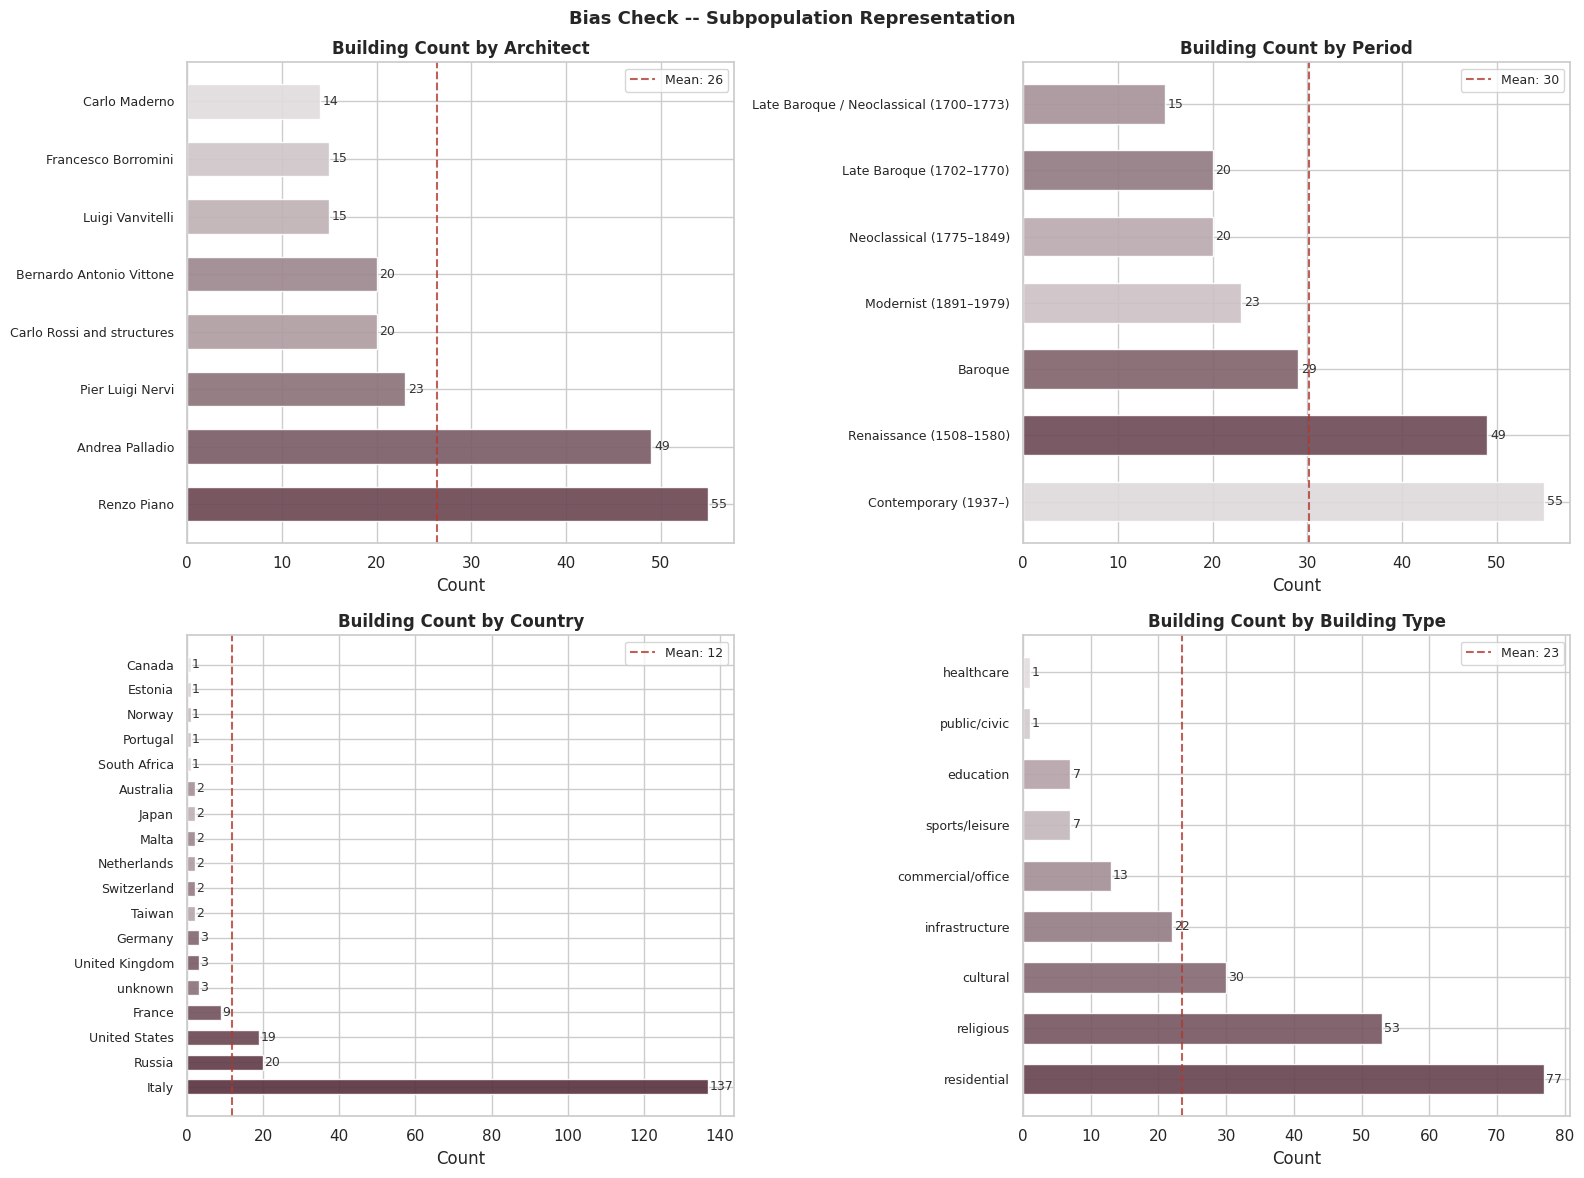

In [18]:
# 6.2 Bias countplots — murdüm gradient
C1, C2, C3, C4, CRED = '#4A1F2D','#6E2F4A','#A85C73','#D9A6B3','#B03A2E'
period_order = [
    'Renaissance (1508–1580)', 'Baroque',
    'Late Baroque (1702–1770)', 'Late Baroque / Neoclassical (1700–1773)',
    'Neoclassical (1775–1849)', 'Modernist (1891–1979)', 'Contemporary (1937–)'
]
bias_settings = [
    ('architect',          'Building Count by Architect'),
    ('architect_period',   'Building Count by Period'),
    ('country_normalized', 'Building Count by Country'),
    ('building_type_group','Building Count by Building Type'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_flat = axes.flatten()

for (col, title), ax in zip(bias_settings, ax_flat):
    order  = (period_order if col == 'architect_period'
              else df[col].value_counts().index.tolist())
    counts = df[col].value_counts().reindex(order).fillna(0)
    vals   = [counts.get(o, 0) for o in order]
    n      = len(order)
    # murdüm gradient: en çok veri en koyu
    grad   = sns.light_palette(C1, n_colors=n+3, reverse=True)[2:-1]
    sorted_pairs  = sorted(zip(vals, order, grad), reverse=True)
    s_vals, s_ord, s_clr = zip(*sorted_pairs)

    bars = ax.barh(list(s_ord), list(s_vals),
                   color=list(s_clr), alpha=0.92, height=0.6)
    mean_val = np.mean(vals)
    ax.axvline(x=mean_val, color=CRED, linestyle='--',
               alpha=0.8, linewidth=1.5, label=f'Mean: {mean_val:.0f}')
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{int(w)}', va='center', fontsize=9, color='#333')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('')
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Bias Check -- Subpopulation Representation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bias_check.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Semantic Outlier Analysis (TF-IDF + Cosine Distance)

Instructor approach:
1. `full_text` vectorised with TfidfVectorizer (stop_words=english, max_features=1000)
2. cosine_distances matrix computed
3. mean(axis=1) per building
4. np.percentile(avg_dist, 90) threshold -- top 10% = semantic outliers

**Layer 1 -- Global:** Most distant from entire corpus.
**Layer 2 -- Group-level:** Most distant within own building_type_group.


In [19]:
# 7.1 TF-IDF vectorisation
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['full_text'].fillna(''))

dist_matrix = cosine_distances(X)
avg_dist    = dist_matrix.mean(axis=1)
df['avg_cosine_dist'] = avg_dist

threshold = np.percentile(avg_dist, 90)
print(f'TF-IDF matrix shape : {X.shape}')
print(f'Threshold (P90)     : {threshold:.4f}')
print(f'Semantic outliers   : {(avg_dist > threshold).sum()}')


TF-IDF matrix shape : (211, 1000)
Threshold (P90)     : 0.9690
Semantic outliers   : 21


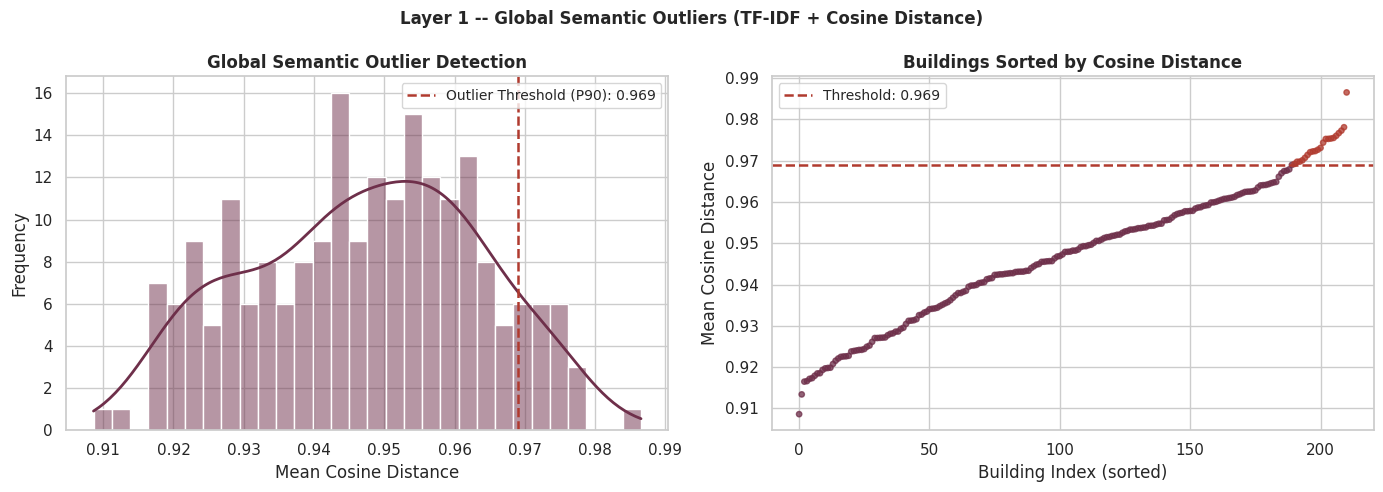

In [20]:
# 7.2 Layer 1 global visualisation
C2, C4, CRED = '#6E2F4A', '#D9A6B3', '#B03A2E'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(avg_dist, kde=True, color=C2, bins=30,
             ax=axes[0], line_kws={'linewidth': 2})
axes[0].axvline(x=threshold, color=CRED, linestyle='--', linewidth=1.8,
                label=f'Outlier Threshold (P90): {threshold:.3f}')
axes[0].set_title('Global Semantic Outlier Detection',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Cosine Distance', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend(fontsize=10)

sorted_dist = np.sort(avg_dist)
colors_sc   = [CRED if d > threshold else C2 for d in sorted_dist]
axes[1].scatter(range(len(sorted_dist)), sorted_dist,
                c=colors_sc, s=15, alpha=0.75)
axes[1].axhline(y=threshold, color=CRED, linestyle='--', linewidth=1.8,
                label=f'Threshold: {threshold:.3f}')
axes[1].set_title('Buildings Sorted by Cosine Distance',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Building Index (sorted)', fontsize=12)
axes[1].set_ylabel('Mean Cosine Distance', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Layer 1 -- Global Semantic Outliers (TF-IDF + Cosine Distance)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('semantic_outlier_global.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# 7.3 Layer 1 outlier list
global_outliers = df[df['avg_cosine_dist']>threshold].copy()
print('Global Semantic Outliers:')
print(global_outliers[['title','architect','building_type_group','avg_cosine_dist']]
      .sort_values('avg_cosine_dist', ascending=False).to_string())
print()
print('Pattern: high-distance buildings use domain-shifted language.')
print('Examples: Tribunal de Paris (legal), IRCAM (acoustic research),')
print('  Orbetello Airfield (WWII military), Kansai Airport (aviation).')


Global Semantic Outliers:
                                                         title                   architect building_type_group  avg_cosine_dist
50                                           Tribunal de Paris                 Renzo Piano           education         0.986519
28                                                       IRCAM                 Renzo Piano           education         0.978089
105                                      Maly Theatre (Moscow)  Carlo Rossi and structures            cultural         0.977276
149                                         Orbetello Airfield            Pier Luigi Nervi      infrastructure         0.976669
13                              California Academy of Sciences                 Renzo Piano            cultural         0.976017
153                                        Pantelleria Airport            Pier Luigi Nervi      infrastructure         0.975505
43                                  Palais des congrès de Lyon                

In [22]:
# 7.4 Layer 2 group-level outliers
group_outliers = []
for group_name, group_df in df.groupby('building_type_group'):
    if len(group_df) < 3:
        continue
    idx = group_df.index.tolist()
    X_g = vectorizer.transform(group_df['full_text'].fillna(''))
    d_g = cosine_distances(X_g).mean(axis=1)
    thr_g = np.percentile(d_g, 90)
    for i, (row_idx, dist) in enumerate(zip(idx, d_g)):
        if dist > thr_g:
            group_outliers.append({
                'title'              : df.loc[row_idx,'title'],
                'architect'          : df.loc[row_idx,'architect'],
                'building_type_group': group_name,
                'group_cosine_dist'  : round(dist, 4)
            })

go_df = pd.DataFrame(group_outliers).sort_values(
    ['building_type_group','group_cosine_dist'], ascending=[True,False])
print('Group-level Semantic Outliers:')
print(go_df.to_string(index=False))


Group-level Semantic Outliers:
                                                    title                  architect building_type_group  group_cosine_dist
                                           Palazzo Thiene            Andrea Palladio   commercial/office             0.8870
                                          Ferrari factory                Renzo Piano   commercial/office             0.8787
                                            Chrysler Hall           Pier Luigi Nervi            cultural             0.9405
                       Jean-Marie Tjibaou Cultural Centre                Renzo Piano            cultural             0.9402
                                          Teatro Olimpico            Andrea Palladio            cultural             0.9397
                               National Library of Russia Carlo Rossi and structures           education             0.8397
                   Santa Maria degli Angeli e dei Martiri           Luigi Vanvitelli      infrastruct

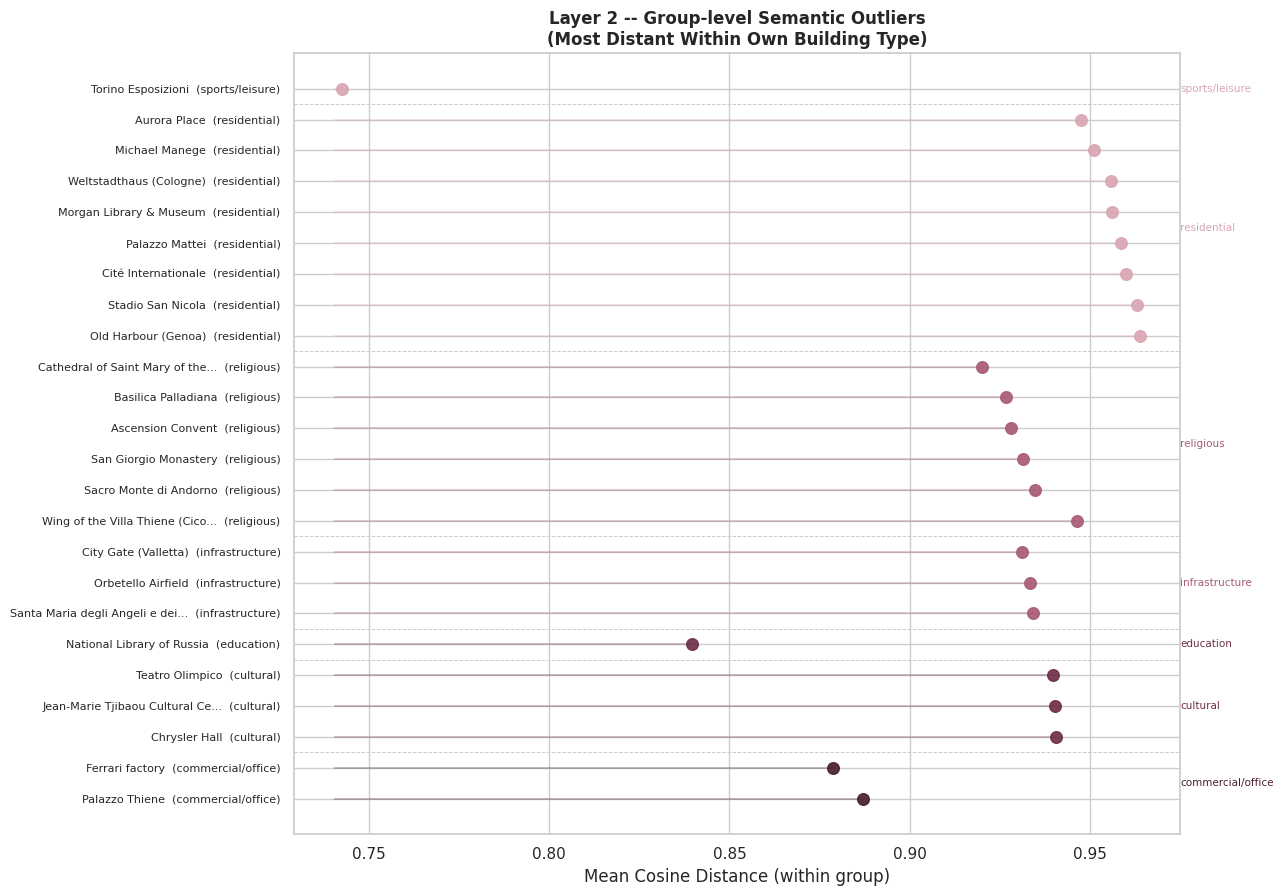

Group outliers may indicate mislabelling or multi-function buildings.


In [23]:
# 7.5 Layer 2 group-level visualisation — lollipop chart
# Her bina ayrı satırda, yazı çakışması yok
C1, C2, C3, C4 = '#4A1F2D','#6E2F4A','#A85C73','#D9A6B3'

# Grup renklerini palet içinden ata
groups_all = sorted(go_df['building_type_group'].unique())
group_colors = dict(zip(groups_all, [C1, C2, C2, C3, C3, C4, C4]))

# Her bina ayrı satır — go_df'yi gruplaşmış ve sıralı yap
go_sorted = go_df.sort_values(['building_type_group','group_cosine_dist'],
                               ascending=[True, False]).reset_index(drop=True)
go_sorted['label'] = go_sorted.apply(
    lambda r: (r['title'][:30]+'...' if len(r['title'])>30 else r['title'])
              + '  (' + r['building_type_group'] + ')', axis=1)

fig, ax = plt.subplots(figsize=(13, max(7, len(go_sorted)*0.38)))

for idx_r, row in go_sorted.iterrows():
    col = group_colors.get(row['building_type_group'], C2)
    # lollipop: çizgi + nokta
    x_start = go_sorted['group_cosine_dist'].min() * 0.997
    ax.hlines(idx_r, x_start, row['group_cosine_dist'],
              color=col, alpha=0.35, linewidth=1.2)
    ax.scatter(row['group_cosine_dist'], idx_r,
               color=col, s=70, zorder=3, alpha=0.92)

ax.set_yticks(range(len(go_sorted)))
ax.set_yticklabels(go_sorted['label'], fontsize=8)
ax.set_xlabel('Mean Cosine Distance (within group)', fontsize=12)
ax.set_title('Layer 2 -- Group-level Semantic Outliers\n'
             '(Most Distant Within Own Building Type)',
             fontsize=12, fontweight='bold')

# Grup aralarına ayraç çizgisi
cumulative = 0
for g in groups_all:
    n_g = len(go_sorted[go_sorted['building_type_group']==g])
    cumulative += n_g
    if cumulative < len(go_sorted):
        ax.axhline(y=cumulative - 0.5, color='#ccc', linewidth=0.7, linestyle='--')
    # Grup etiketi (sağ taraf)
    mid = cumulative - n_g/2 - 0.5
    ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] else go_sorted['group_cosine_dist'].max(),
            mid, g, fontsize=7.5, color=group_colors.get(g, C2),
            va='center', ha='left')

plt.tight_layout()
plt.savefig('semantic_outlier_group.png', dpi=300, bbox_inches='tight')
plt.show()
print('Group outliers may indicate mislabelling or multi-function buildings.')
